In [1]:
# !pip install -e .[cplex]

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)

from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path
from qiskit.quantum_info.random import random_unitary
from gulps.cts_linear_program import ContinuousISAConstraints
import numpy as np
from tqdm import tqdm


def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()

In [7]:
base = GateInvariants.from_unitary(fsim(np.pi / 2, np.pi / 6))
solver = ContinuousISAConstraints(base=base, sequence_length=8, offset=1e-6)

[0.9350649350649352, 0.0779220779220778, 0.07792207792207788] 1.0909090909090908


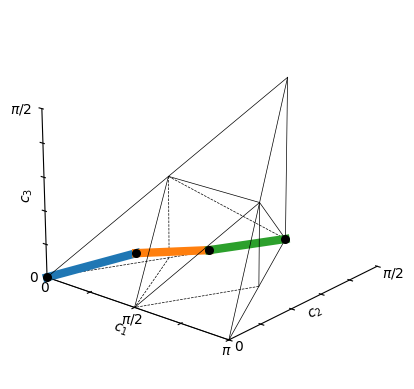

In [10]:
target = GateInvariants.from_unitary(iSwapGate())
# target = GateInvariants.from_unitary(random_unitary(dims=4))

gi_list, intermediates, ks = cts_solve(solver, target)
print(ks, sum(ks))

from gulps.utils.visualize import render_path

render_path(intermediates);

In [160]:
from gulps.gulps_decomposer import GulpsDecomposer

isa = [
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 7), 1 / 7, "sqrt7fsim"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(
    gate_set=gate_set, costs=costs, names=names, precompute_polytopes=False
)

1.0952380952380951


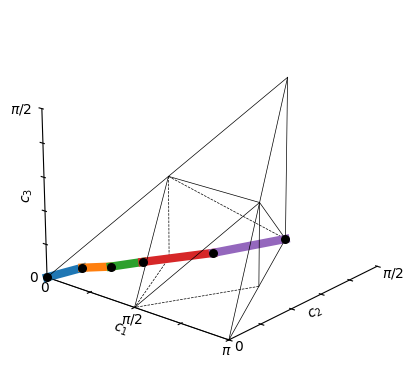

In [161]:
sentence_out, example_intermediates = decomposer._best_decomposition(target_inv=target)
print(sum(decomposer.isa.cost_dict[g] for g in sentence_out))
render_path(example_intermediates);

100%|██████████| 10000/10000 [05:52<00:00, 28.37it/s]


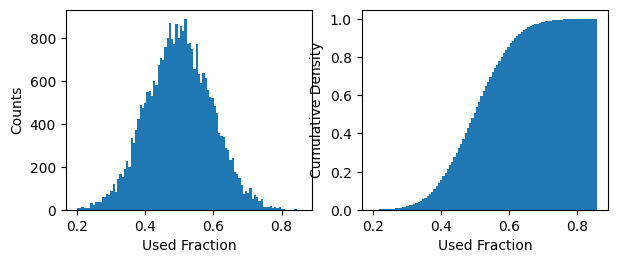

In [ ]:
from qiskit.circuit.library import RXXGate

zz_base = GateInvariants.from_unitary(RXXGate(theta=np.pi / 2))
zz_solver = ContinuousISAConstraints(base=zz_base, sequence_length=8)
used_fractions = []
N = 10_000
for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    gi_list, intermediates, ks = cts_solve(zz_solver, target)
    used_fractions.extend(ks)

# histogram of used fractions
import matplotlib.pyplot as plt

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()

100%|██████████| 10000/10000 [06:04<00:00, 27.41it/s]


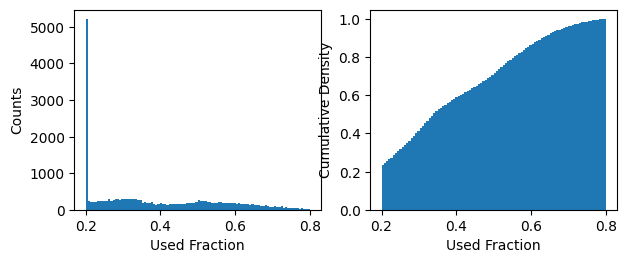

In [ ]:
fsim_base = GateInvariants.from_unitary(fsim(np.pi / 2, np.pi / 6).power(1.0))
fsim_solver = ContinuousISAConstraints(base=fsim_base, sequence_length=8)

used_fractions = []
for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    gi_list, intermediates, ks = cts_solve(fsim_solver, target)
    used_fractions.extend(ks)

# histogram of used fractions
import matplotlib.pyplot as plt

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()

In [169]:
iswap_base = GateInvariants.from_unitary(iSwapGate().power(1.0))
iswap_solver = ContinuousISAConstraints(base=iswap_base, sequence_length=8)
used_fractions = []
for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    gi_list, intermediates, ks = cts_solve(iswap_solver, target)
    used_fractions.extend(ks)

# histogram of used fractions
import matplotlib.pyplot as plt

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()

 75%|███████▍  | 7461/10000 [03:08<01:04, 39.60it/s]


TypeError: 'NoneType' object is not iterable

100%|██████████| 400/400 [00:15<00:00, 26.30it/s]


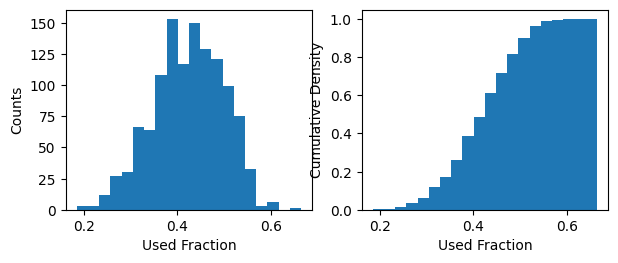

In [6]:
swap_base = GateInvariants.from_unitary(SwapGate().power(1.0))
swap_solver = ContinuousISAConstraints(base=swap_base, sequence_length=8)
used_fractions = []
for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    gi_list, intermediates, ks = cts_solve(swap_solver, target)
    used_fractions.extend(ks)

# histogram of used fractions
import matplotlib.pyplot as plt

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()

In [ ]:
from gulps.utils.isa import expected_costs
from gulps.gulps_decomposer import GulpsDecomposer

x = np.linspace(0.2, 1.0, 10)
y = []
for c in tqdm(x):
    isa = [
        (iSwapGate().power(c), c, "U"),
    ]
    gate_set, costs, names = zip(*isa)
    decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)
    if hasattr(decomposer.isa, "coverage_set"):
        y.append(expected_costs(decomposer.isa.coverage_set))

# print (y[0] vs x; y[1] vs x; y[2] vs x)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(3 * 3.5, 3.0))
axs = axes[0]
axs.plot(x, [v[0] for v in y], "-o")
axs.set_xlabel("U^x")
axs.set_ylabel("expected cost")

axs = axes[1]
axs.plot(x, [v[1] for v in y], "-o")
axs.set_xlabel("U^x")
axs.set_ylabel("expected depth")

  0%|          | 0/10 [00:00<?, ?it/s]